In [1]:
#Import libraries
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
from sklearn.metrics import confusion_matrix

C:\Users\matth\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\matth\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\matth\AppData\Local\Temp\ipykernel_12488\3315401272.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
#Read in data
hotel_data = pd.read_csv('Hotel Reservations.csv')

In [3]:
#Duplicate check
print(hotel_data.duplicated().value_counts())

False    36275
Name: count, dtype: int64


In [4]:
#Missing value check
print(hotel_data.isnull().sum())

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


In [5]:
print(hotel_data.isna().sum())

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64


In [6]:
#Print data types for quantitative versus categorical data check
print(hotel_data.dtypes)

Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object


In [7]:
#Booking status should be a binary outcome with Canceled as 1 and Not_Canceled as 0
# Reclassify the 'Status' column
hotel_data['booking_status'] = hotel_data['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})
print(hotel_data.dtypes)

Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                            int64
dtype: object


In [8]:
hotel_data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,0
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,0
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,1
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,1
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,1


In [9]:
#Interested in seeing unique value counts for each quantitative variable,
#maybe we could recode some as binary if it would be more helpful for interpretation
print(hotel_data.no_of_adults.value_counts())

no_of_adults
2    26108
1     7695
3     2317
0      139
4       16
Name: count, dtype: int64


In [10]:
print(hotel_data.no_of_children.value_counts())

no_of_children
0     33577
1      1618
2      1058
3        19
9         2
10        1
Name: count, dtype: int64


In [11]:
print(hotel_data.no_of_weekend_nights.value_counts())

no_of_weekend_nights
0    16872
1     9995
2     9071
3      153
4      129
5       34
6       20
7        1
Name: count, dtype: int64


In [12]:
print(hotel_data.no_of_week_nights.value_counts())

no_of_week_nights
2     11444
1      9488
3      7839
4      2990
0      2387
5      1614
6       189
7       113
10       62
8        62
9        34
11       17
15       10
12        9
14        7
13        5
17        3
16        2
Name: count, dtype: int64


In [13]:
print(hotel_data.required_car_parking_space.value_counts())

required_car_parking_space
0    35151
1     1124
Name: count, dtype: int64


In [14]:
print(hotel_data.lead_time.value_counts()) #Will need to explain what this is in report

lead_time
0      1297
1      1078
2       643
3       630
4       628
       ... 
300       1
353       1
328       1
352       1
351       1
Name: count, Length: 352, dtype: int64


In [15]:
print(hotel_data.arrival_year.value_counts()) #Could there be more or less based on year

arrival_year
2018    29761
2017     6514
Name: count, dtype: int64


In [16]:
print(hotel_data.arrival_month.value_counts()) #More or less cancellations during summer?

arrival_month
10    5317
9     4611
8     3813
6     3203
12    3021
11    2980
7     2920
4     2736
5     2598
3     2358
2     1704
1     1014
Name: count, dtype: int64


In [17]:
print(hotel_data.arrival_date.value_counts()) #More or less cancellations during beginning, middle, end of month?

arrival_date
13    1358
17    1345
2     1331
4     1327
19    1327
16    1306
20    1281
15    1273
6     1273
18    1260
14    1242
30    1216
12    1204
8     1198
29    1190
21    1158
5     1154
26    1146
25    1146
1     1133
9     1130
28    1129
7     1110
24    1103
11    1098
3     1098
10    1089
27    1059
22    1023
23     990
31     578
Name: count, dtype: int64


In [18]:
print(hotel_data.repeated_guest.value_counts()) #Do repeated guests cancel less?

repeated_guest
0    35345
1      930
Name: count, dtype: int64


In [19]:
print(hotel_data.no_of_previous_cancellations.value_counts()) #Could re-map to "Has the guest cancelled before?" and add as new column

no_of_previous_cancellations
0     35937
1       198
2        46
3        43
11       25
5        11
4        10
13        4
6         1
Name: count, dtype: int64


In [20]:
print(hotel_data.no_of_previous_bookings_not_canceled.value_counts())

no_of_previous_bookings_not_canceled
0     35463
1       228
2       112
3        80
4        65
5        60
6        36
7        24
8        23
10       19
9        19
11       15
12       12
14        9
15        8
16        7
13        7
18        6
20        6
21        6
17        6
19        6
22        6
25        3
27        3
24        3
23        3
44        2
29        2
48        2
28        2
30        2
32        2
31        2
26        2
46        1
55        1
45        1
57        1
53        1
54        1
58        1
41        1
40        1
43        1
35        1
50        1
56        1
33        1
37        1
42        1
51        1
38        1
34        1
39        1
52        1
49        1
47        1
36        1
Name: count, dtype: int64


In [21]:
print(hotel_data.avg_price_per_room.value_counts())

avg_price_per_room
65.00     848
75.00     826
90.00     703
95.00     669
115.00    662
         ... 
212.42      1
83.48       1
70.42       1
130.99      1
167.80      1
Name: count, Length: 3930, dtype: int64


In [22]:
print(hotel_data.no_of_special_requests.value_counts()) #Could re-map to "Made a special request?" and add as a new column

no_of_special_requests
0    19777
1    11373
2     4364
3      675
4       78
5        8
Name: count, dtype: int64


In [23]:
print(hotel_data.booking_status.value_counts())

booking_status
0    24390
1    11885
Name: count, dtype: int64


In [24]:
#Combine certain columns to see if when combined they have more predictive power
#'Length of stay', 'Count of guests', 'Count of Previous Bookings'
hotel_data['length_of_stay'] = hotel_data['no_of_weekend_nights'] + hotel_data['no_of_week_nights']
hotel_data['count_of_guests'] = hotel_data['no_of_adults'] + hotel_data['no_of_children']
hotel_data['count_of_previous_bookings'] = hotel_data['no_of_previous_cancellations'] + hotel_data['no_of_previous_bookings_not_canceled']

In [25]:
print(hotel_data.length_of_stay.value_counts())

length_of_stay
3     10052
2      8472
1      6604
4      5893
5      2589
6      1031
7       973
8       179
9       111
10      109
0        78
11       39
14       32
15       31
12       24
13       18
20       11
19        6
16        6
17        5
21        4
18        3
23        2
22        2
24        1
Name: count, dtype: int64


In [26]:
print(hotel_data.count_of_guests.value_counts())

count_of_guests
2     23942
1      7552
3      3851
4       912
5        15
12        1
10        1
11        1
Name: count, dtype: int64


In [27]:
print(hotel_data.count_of_previous_bookings.value_counts())

count_of_previous_bookings
0     35345
1       322
2       113
3        78
4        60
      ...  
57        1
37        1
54        1
36        1
35        1
Name: count, Length: 63, dtype: int64


In [28]:
#Create new columns for 'Has the guest cancelled before?' and 'Made a special request?'
hotel_data['prior_cancellation'] = hotel_data['no_of_previous_cancellations'].apply(lambda x: 0 if x == 0 else 1)
print(hotel_data.prior_cancellation.value_counts())

prior_cancellation
0    35937
1      338
Name: count, dtype: int64


In [29]:
hotel_data['special_request_flag'] = hotel_data['no_of_special_requests'].apply(lambda x: 0 if x == 0 else 1)
print(hotel_data.special_request_flag.value_counts())

special_request_flag
0    19777
1    16498
Name: count, dtype: int64


In [30]:
#Outlier check for quantitative continuous variables
#All values seem legitimate so not really a need to treat outliers

#no_of_adults
##Outlier assessment via histogram
hotel_data['Z_Score_no_of_adults']=stats.zscore(hotel_data['no_of_adults'])
hotel_data[['no_of_adults', 'Z_Score_no_of_adults']].head

<bound method NDFrame.head of        no_of_adults  Z_Score_no_of_adults
0                 2              0.298893
1                 2              0.298893
2                 1             -1.628975
3                 2              0.298893
4                 2              0.298893
...             ...                   ...
36270             3              2.226761
36271             2              0.298893
36272             2              0.298893
36273             2              0.298893
36274             2              0.298893

[36275 rows x 2 columns]>

(array([1.3900e+02, 0.0000e+00, 7.6950e+03, 0.0000e+00, 0.0000e+00,
        2.6108e+04, 0.0000e+00, 2.3170e+03, 0.0000e+00, 1.6000e+01]),
 array([-3.55684355, -2.78569631, -2.01454908, -1.24340184, -0.47225461,
         0.29889263,  1.07003987,  1.8411871 ,  2.61233434,  3.38348157,
         4.15462881]),
 <BarContainer object of 10 artists>)

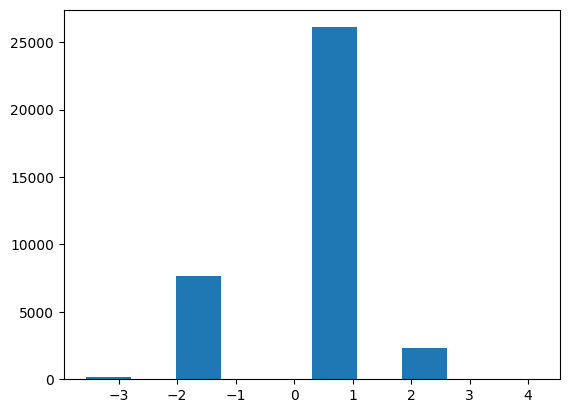

In [31]:
plt.hist(hotel_data['Z_Score_no_of_adults'])

In [32]:
#no_of_children
##Outlier assessment via histogram
hotel_data['Z_Score_no_of_children']=stats.zscore(hotel_data['no_of_children'])
hotel_data[['no_of_children', 'Z_Score_no_of_children']].head

<bound method NDFrame.head of        no_of_children  Z_Score_no_of_children
0                   0                -0.26147
1                   0                -0.26147
2                   0                -0.26147
3                   0                -0.26147
4                   0                -0.26147
...               ...                     ...
36270               0                -0.26147
36271               0                -0.26147
36272               0                -0.26147
36273               0                -0.26147
36274               0                -0.26147

[36275 rows x 2 columns]>

(array([3.3577e+04, 1.6180e+03, 1.0580e+03, 1.9000e+01, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00]),
 array([-0.26147045,  2.22212223,  4.70571492,  7.1893076 ,  9.67290028,
        12.15649296, 14.64008564, 17.12367832, 19.607271  , 22.09086369,
        24.57445637]),
 <BarContainer object of 10 artists>)

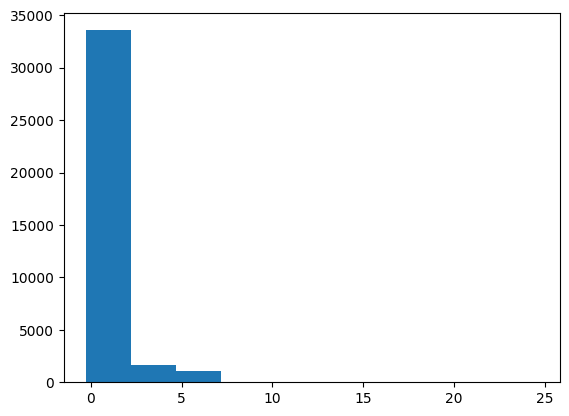

In [33]:
plt.hist(hotel_data['Z_Score_no_of_children'])

In [34]:
#no_of_weekend_nights
##Outlier assessment via histogram
hotel_data['Z_Score_no_of_weekend_nights']=stats.zscore(hotel_data['no_of_weekend_nights'])
hotel_data[['no_of_weekend_nights', 'Z_Score_no_of_weekend_nights']].head

<bound method NDFrame.head of        no_of_weekend_nights  Z_Score_no_of_weekend_nights
0                         1                      0.217401
1                         2                      1.365993
2                         2                      1.365993
3                         0                     -0.931190
4                         1                      0.217401
...                     ...                           ...
36270                     2                      1.365993
36271                     1                      0.217401
36272                     2                      1.365993
36273                     0                     -0.931190
36274                     1                      0.217401

[36275 rows x 2 columns]>

(array([1.6872e+04, 9.9950e+03, 9.0710e+03, 0.0000e+00, 1.5300e+02,
        1.2900e+02, 0.0000e+00, 3.4000e+01, 2.0000e+01, 1.0000e+00]),
 array([-0.93119021, -0.12717622,  0.67683777,  1.48085176,  2.28486576,
         3.08887975,  3.89289374,  4.69690773,  5.50092173,  6.30493572,
         7.10894971]),
 <BarContainer object of 10 artists>)

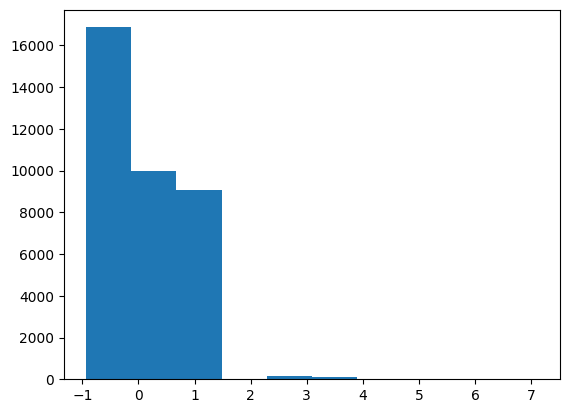

In [35]:
plt.hist(hotel_data['Z_Score_no_of_weekend_nights'])

In [36]:
#no_of_week_nights
##Outlier assessment via histogram
hotel_data['Z_Score_no_of_week_nights']=stats.zscore(hotel_data['no_of_week_nights'])
hotel_data[['no_of_week_nights', 'Z_Score_no_of_week_nights']].head

<bound method NDFrame.head of        no_of_week_nights  Z_Score_no_of_week_nights
0                      2                  -0.144803
1                      3                   0.563972
2                      1                  -0.853578
3                      2                  -0.144803
4                      1                  -0.853578
...                  ...                        ...
36270                  6                   2.690296
36271                  3                   0.563972
36272                  6                   2.690296
36273                  3                   0.563972
36274                  2                  -0.144803

[36275 rows x 2 columns]>

(array([1.1875e+04, 1.9283e+04, 4.6040e+03, 1.8900e+02, 1.7500e+02,
        9.6000e+01, 1.7000e+01, 1.4000e+01, 1.7000e+01, 5.0000e+00]),
 array([-1.5623526 , -0.35743547,  0.84748167,  2.0523988 ,  3.25731593,
         4.46223307,  5.6671502 ,  6.87206733,  8.07698447,  9.2819016 ,
        10.48681873]),
 <BarContainer object of 10 artists>)

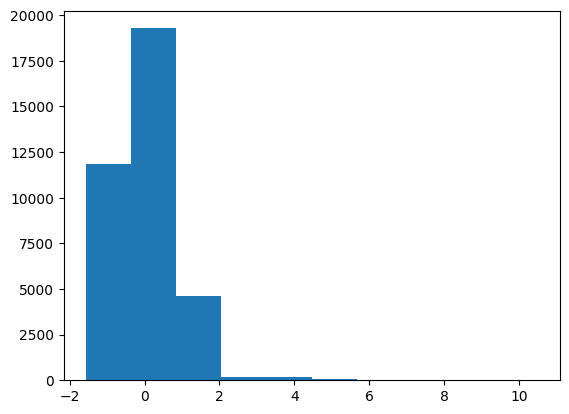

In [37]:
plt.hist(hotel_data['Z_Score_no_of_week_nights'])

In [38]:
#lead_time
##Outlier assessment via histogram
hotel_data['Z_Score_lead_time']=stats.zscore(hotel_data['lead_time'])
hotel_data[['lead_time', 'Z_Score_lead_time']].head

<bound method NDFrame.head of        lead_time  Z_Score_lead_time
0            224           1.614896
1              5          -0.933701
2              1          -0.980250
3            211           1.463610
4             48          -0.433291
...          ...                ...
36270         85          -0.002706
36271        228           1.661446
36272        148           0.730452
36273         63          -0.258730
36274        207           1.417060

[36275 rows x 2 columns]>

(array([15803.,  7213.,  4655.,  3080.,  2253.,  1209.,  1314.,   483.,
          163.,   102.]),
 array([-0.99188783, -0.47634973,  0.03918838,  0.55472649,  1.0702646 ,
         1.5858027 ,  2.10134081,  2.61687892,  3.13241703,  3.64795513,
         4.16349324]),
 <BarContainer object of 10 artists>)

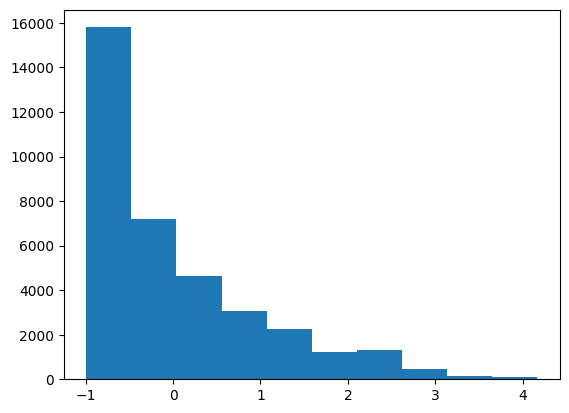

In [39]:
plt.hist(hotel_data['Z_Score_lead_time'])

In [40]:
#no_of_previous_cancellations
##Outlier assessment via histogram
hotel_data['Z_Score_no_of_previous_cancellations']=stats.zscore(hotel_data['no_of_previous_cancellations'])
hotel_data[['no_of_previous_cancellations', 'Z_Score_no_of_previous_cancellations']].head

<bound method NDFrame.head of        no_of_previous_cancellations  Z_Score_no_of_previous_cancellations
0                                 0                             -0.063393
1                                 0                             -0.063393
2                                 0                             -0.063393
3                                 0                             -0.063393
4                                 0                             -0.063393
...                             ...                                   ...
36270                             0                             -0.063393
36271                             0                             -0.063393
36272                             0                             -0.063393
36273                             0                             -0.063393
36274                             0                             -0.063393

[36275 rows x 2 columns]>

(array([3.6135e+04, 4.6000e+01, 4.3000e+01, 2.1000e+01, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 2.5000e+01, 4.0000e+00]),
 array([-0.06339327,  3.46608521,  6.99556369, 10.52504217, 14.05452065,
        17.58399913, 21.11347761, 24.64295609, 28.17243457, 31.70191305,
        35.23139153]),
 <BarContainer object of 10 artists>)

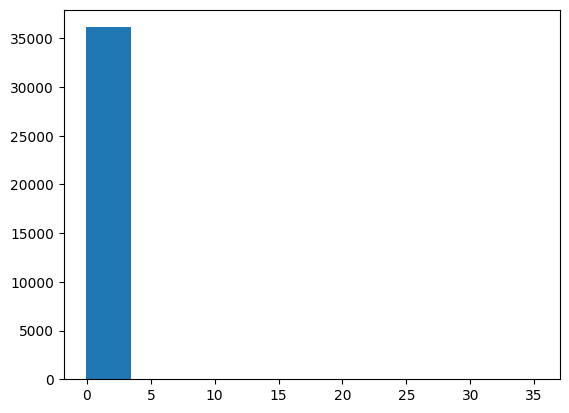

In [41]:
plt.hist(hotel_data['Z_Score_no_of_previous_cancellations'])

In [42]:
#no_of_previous_bookings_not_canceled
##Outlier assessment via histogram
hotel_data['Z_Score_no_of_previous_bookings_not_canceled']=stats.zscore(hotel_data['no_of_previous_bookings_not_canceled'])
hotel_data[['no_of_previous_bookings_not_canceled', 'Z_Score_no_of_previous_bookings_not_canceled']].head

<bound method NDFrame.head of        no_of_previous_bookings_not_canceled  \
0                                         0   
1                                         0   
2                                         0   
3                                         0   
4                                         0   
...                                     ...   
36270                                     0   
36271                                     0   
36272                                     0   
36273                                     0   
36274                                     0   

       Z_Score_no_of_previous_bookings_not_canceled  
0                                         -0.087456  
1                                         -0.087456  
2                                         -0.087456  
3                                         -0.087456  
4                                         -0.087456  
...                                             ...  
36270                      

(array([3.6008e+04, 1.3600e+02, 4.9000e+01, 3.3000e+01, 1.3000e+01,
        1.0000e+01, 6.0000e+00, 7.0000e+00, 7.0000e+00, 6.0000e+00]),
 array([-0.08745646,  3.2189948 ,  6.52544605,  9.8318973 , 13.13834855,
        16.44479981, 19.75125106, 23.05770231, 26.36415357, 29.67060482,
        32.97705607]),
 <BarContainer object of 10 artists>)

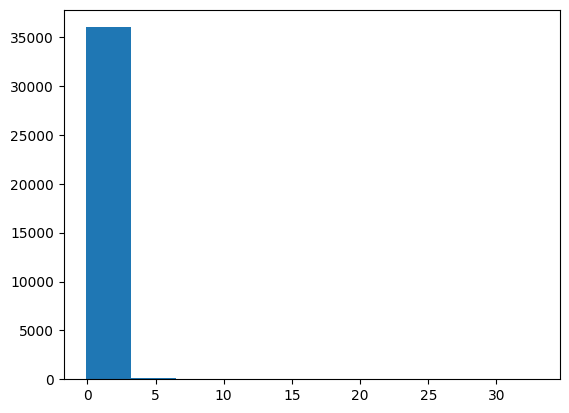

In [43]:
plt.hist(hotel_data['Z_Score_no_of_previous_bookings_not_canceled'])

In [44]:
#avg_price_per_room
##Outlier assessment via histogram
hotel_data['Z_Score_avg_price_per_room']=stats.zscore(hotel_data['avg_price_per_room'])
hotel_data[['avg_price_per_room', 'Z_Score_avg_price_per_room']].head

<bound method NDFrame.head of        avg_price_per_room  Z_Score_avg_price_per_room
0                   65.00                   -1.095033
1                  106.68                    0.092806
2                   60.00                   -1.237528
3                  100.00                   -0.097567
4                   94.50                   -0.254312
...                   ...                         ...
36270              167.80                    1.834665
36271               90.95                   -0.355483
36272               98.39                   -0.143451
36273               94.50                   -0.254312
36274              161.67                    1.659966

[36275 rows x 2 columns]>

(array([1.0810e+03, 2.0645e+04, 1.2570e+04, 1.6970e+03, 2.5100e+02,
        2.6000e+01, 4.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-2.94746829, -1.40852185,  0.1304246 ,  1.66937104,  3.20831748,
         4.74726393,  6.28621037,  7.82515682,  9.36410326, 10.9030497 ,
        12.44199615]),
 <BarContainer object of 10 artists>)

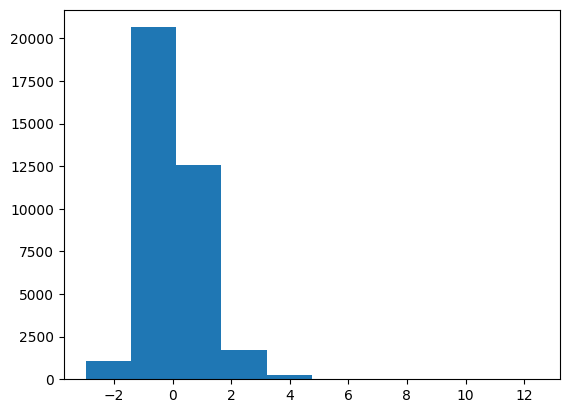

In [45]:
plt.hist(hotel_data['Z_Score_avg_price_per_room'])

In [46]:
#no_of_special_requests
##Outlier assessment via histogram
hotel_data['Z_Score_no_of_special_requests']=stats.zscore(hotel_data['no_of_special_requests'])
hotel_data[['no_of_special_requests', 'Z_Score_no_of_special_requests']].head

<bound method NDFrame.head of        no_of_special_requests  Z_Score_no_of_special_requests
0                           0                       -0.788140
1                           1                        0.483760
2                           0                       -0.788140
3                           0                       -0.788140
4                           0                       -0.788140
...                       ...                             ...
36270                       1                        0.483760
36271                       2                        1.755661
36272                       2                        1.755661
36273                       0                       -0.788140
36274                       0                       -0.788140

[36275 rows x 2 columns]>

(array([1.9777e+04, 0.0000e+00, 1.1373e+04, 4.3640e+03, 0.0000e+00,
        0.0000e+00, 6.7500e+02, 0.0000e+00, 7.8000e+01, 8.0000e+00]),
 array([-0.78813999, -0.15218977,  0.48376045,  1.11971067,  1.75566089,
         2.39161111,  3.02756133,  3.66351155,  4.29946177,  4.93541199,
         5.5713622 ]),
 <BarContainer object of 10 artists>)

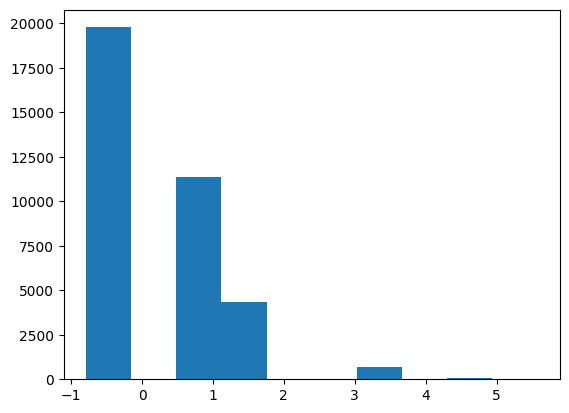

In [47]:
plt.hist(hotel_data['Z_Score_no_of_special_requests'])

In [48]:
#length_of_stay
##Outlier assessment via histogram
hotel_data['Z_Score_length_of_stay']=stats.zscore(hotel_data['length_of_stay'])
hotel_data[['length_of_stay', 'Z_Score_length_of_stay']].head

<bound method NDFrame.head of        length_of_stay  Z_Score_length_of_stay
0                   3               -0.008412
1                   5                1.111414
2                   3               -0.008412
3                   2               -0.568325
4                   2               -0.568325
...               ...                     ...
36270               8                2.791152
36271               4                0.551501
36272               8                2.791152
36273               3               -0.008412
36274               3               -0.008412

[36275 rows x 2 columns]>

(array([1.5154e+04, 1.5945e+04, 4.5930e+03, 2.9000e+02, 1.4800e+02,
        7.4000e+01, 3.7000e+01, 1.4000e+01, 1.5000e+01, 5.0000e+00]),
 array([-1.68815098, -0.34435996,  0.99943107,  2.34322209,  3.68701311,
         5.03080413,  6.37459516,  7.71838618,  9.0621772 , 10.40596822,
        11.74975924]),
 <BarContainer object of 10 artists>)

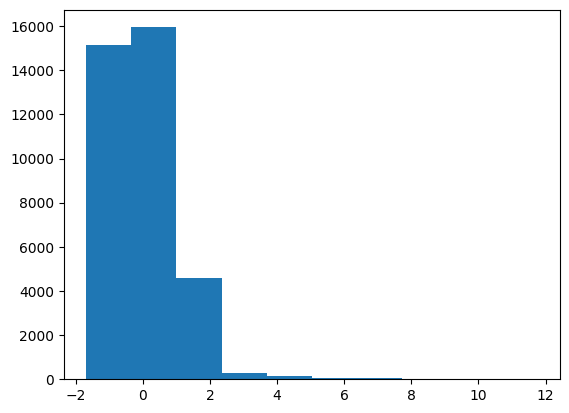

In [49]:
plt.hist(hotel_data['Z_Score_length_of_stay'])

In [50]:
#count_of_guests
##Outlier assessment via histogram
hotel_data['Z_Score_count_of_guests']=stats.zscore(hotel_data['count_of_guests'])
hotel_data[['count_of_guests', 'Z_Score_count_of_guests']].head

<bound method NDFrame.head of        count_of_guests  Z_Score_count_of_guests
0                    2                 0.076515
1                    2                 0.076515
2                    1                -1.461195
3                    2                 0.076515
4                    2                 0.076515
...                ...                      ...
36270                3                 1.614224
36271                2                 0.076515
36272                2                 0.076515
36273                2                 0.076515
36274                2                 0.076515

[36275 rows x 2 columns]>

(array([3.1494e+04, 3.8510e+03, 9.1200e+02, 1.5000e+01, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 2.0000e+00]),
 array([-1.46119479,  0.23028549,  1.92176576,  3.61324603,  5.3047263 ,
         6.99620657,  8.68768684, 10.37916711, 12.07064738, 13.76212765,
        15.45360792]),
 <BarContainer object of 10 artists>)

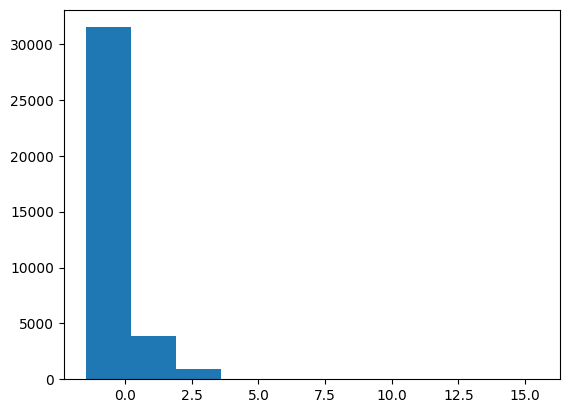

In [51]:
plt.hist(hotel_data['Z_Score_count_of_guests'])

In [52]:
#count_of_previous_bookings
##Outlier assessment via histogram
hotel_data['Z_Score_count_of_previous_bookings']=stats.zscore(hotel_data['count_of_previous_bookings'])
hotel_data[['count_of_previous_bookings', 'Z_Score_count_of_previous_bookings']].head

<bound method NDFrame.head of        count_of_previous_bookings  Z_Score_count_of_previous_bookings
0                               0                           -0.090467
1                               0                           -0.090467
2                               0                           -0.090467
3                               0                           -0.090467
4                               0                           -0.090467
...                           ...                                 ...
36270                           0                           -0.090467
36271                           0                           -0.090467
36272                           0                           -0.090467
36273                           0                           -0.090467
36274                           0                           -0.090467

[36275 rows x 2 columns]>

(array([3.6004e+04, 1.2600e+02, 6.2000e+01, 3.0000e+01, 1.9000e+01,
        9.0000e+00, 6.0000e+00, 7.0000e+00, 6.0000e+00, 6.0000e+00]),
 array([-0.09046676,  3.1850734 ,  6.46061357,  9.73615374, 13.0116939 ,
        16.28723407, 19.56277424, 22.8383144 , 26.11385457, 29.38939473,
        32.6649349 ]),
 <BarContainer object of 10 artists>)

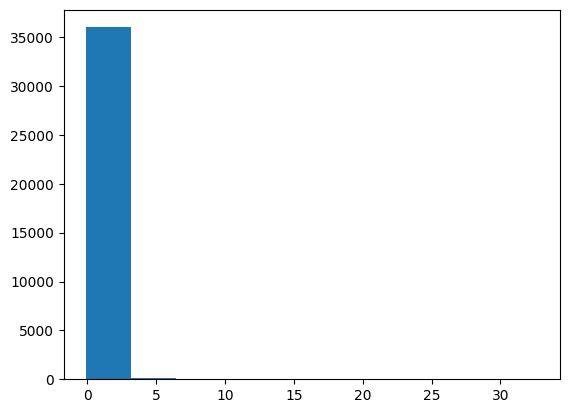

In [53]:
plt.hist(hotel_data['Z_Score_count_of_previous_bookings'])

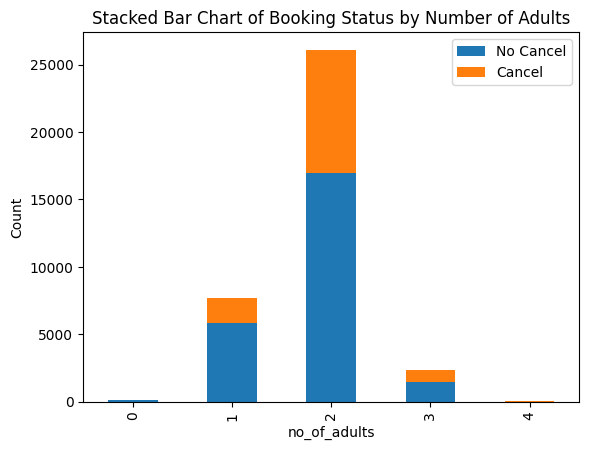

In [54]:
#Bivariate visualizations for all numerical variables using booking_status as target variable

##no_of_adults
ct_no_of_adults = pd.crosstab(hotel_data['no_of_adults'], hotel_data['booking_status'])
ct_no_of_adults.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Number of Adults')
plt.legend(["No Cancel", "Cancel"])
plt.show()

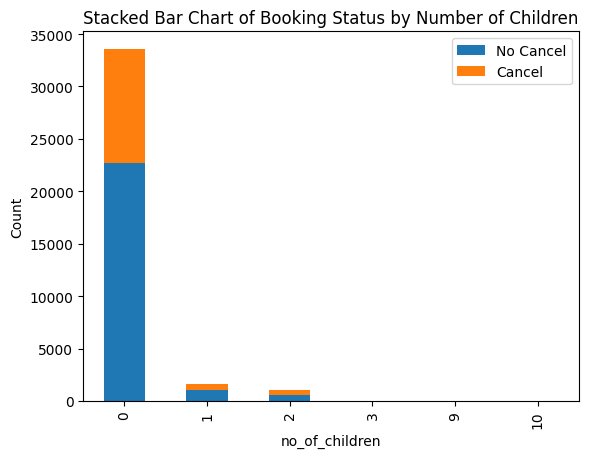

In [55]:
##no_of_children
ct_no_of_children = pd.crosstab(hotel_data['no_of_children'], hotel_data['booking_status'])
ct_no_of_children.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Number of Children')
plt.legend(["No Cancel", "Cancel"])
plt.show()

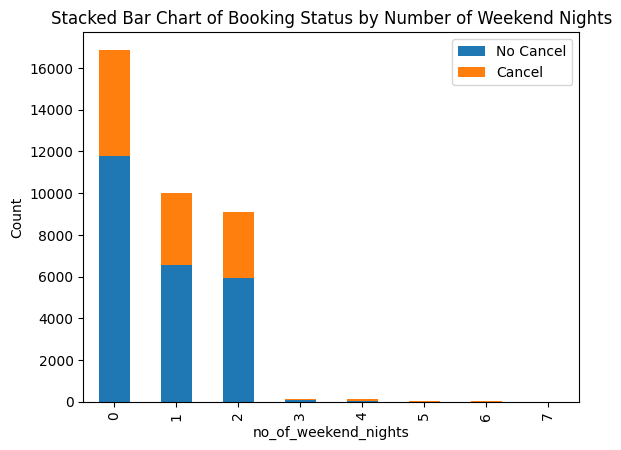

In [56]:
##no_of_weekend_nights
ct_no_of_weekend_nights = pd.crosstab(hotel_data['no_of_weekend_nights'], hotel_data['booking_status'])
ct_no_of_weekend_nights.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Number of Weekend Nights')
plt.legend(["No Cancel", "Cancel"])
plt.show()

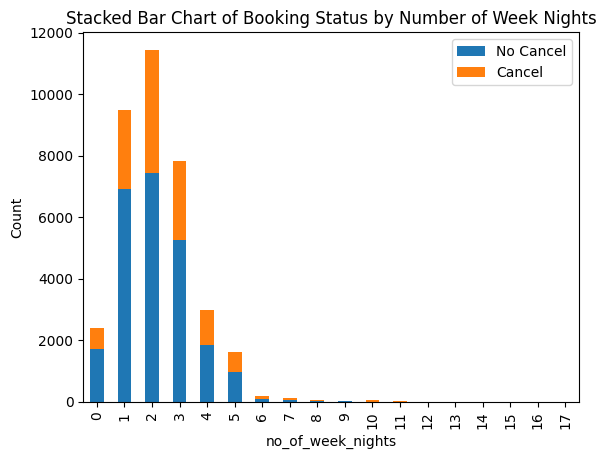

In [57]:
##no_of_week_nights
ct_no_of_week_nights = pd.crosstab(hotel_data['no_of_week_nights'], hotel_data['booking_status'])
ct_no_of_week_nights.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Number of Week Nights')
plt.legend(["No Cancel", "Cancel"])
plt.show()

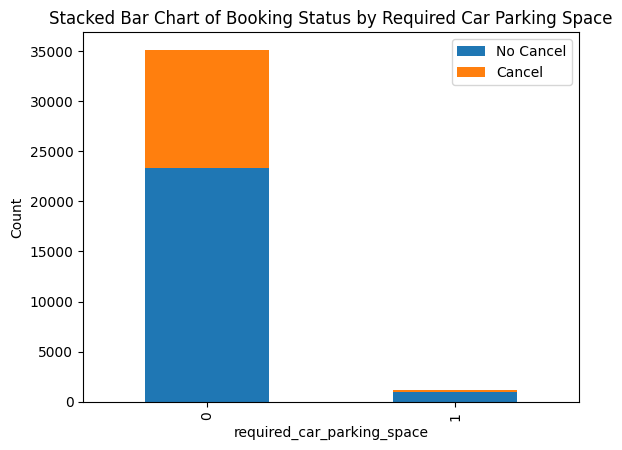

In [58]:
##required_car_parking_space
ct_required_car_parking_space = pd.crosstab(hotel_data['required_car_parking_space'], hotel_data['booking_status'])
ct_required_car_parking_space.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Required Car Parking Space')
plt.legend(["No Cancel", "Cancel"])
plt.show()

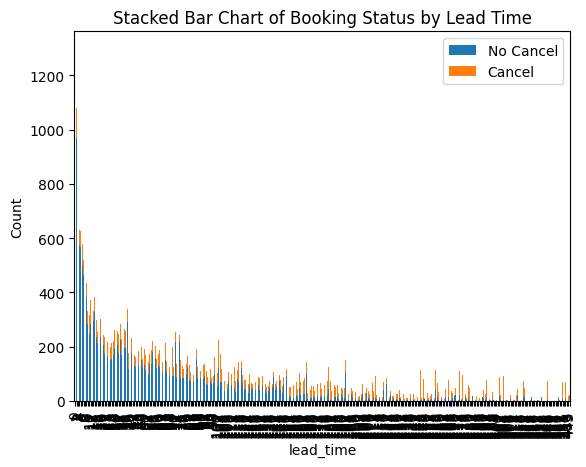

In [59]:
##lead_time - put these into buckets below and see if that shows anything different
ct_lead_time = pd.crosstab(hotel_data['lead_time'], hotel_data['booking_status'])
ct_lead_time.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Lead Time')
plt.legend(["No Cancel", "Cancel"])
plt.show()

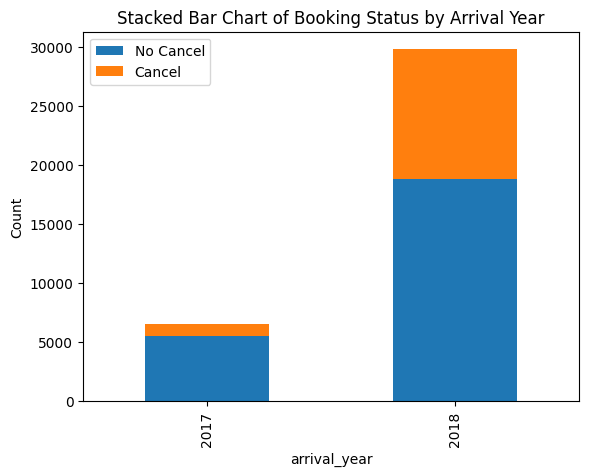

In [60]:
##arrival_year
ct_arrival_year = pd.crosstab(hotel_data['arrival_year'], hotel_data['booking_status'])
ct_arrival_year.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Arrival Year')
plt.legend(["No Cancel", "Cancel"])
plt.show()

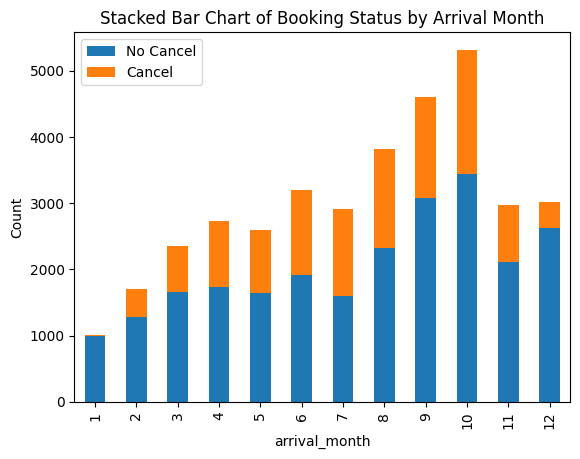

In [61]:
##arrival_month
ct_arrival_month = pd.crosstab(hotel_data['arrival_month'], hotel_data['booking_status'])
ct_arrival_month.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Arrival Month')
plt.legend(["No Cancel", "Cancel"])
plt.show()

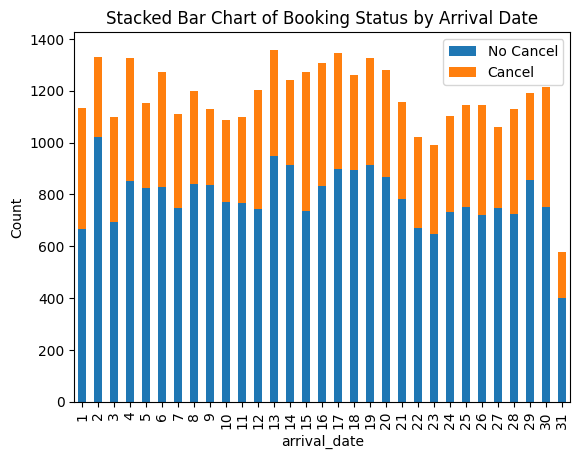

In [62]:
##arrival_date
ct_arrival_date = pd.crosstab(hotel_data['arrival_date'], hotel_data['booking_status'])
ct_arrival_date.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Arrival Date')
plt.legend(["No Cancel", "Cancel"])
plt.show()

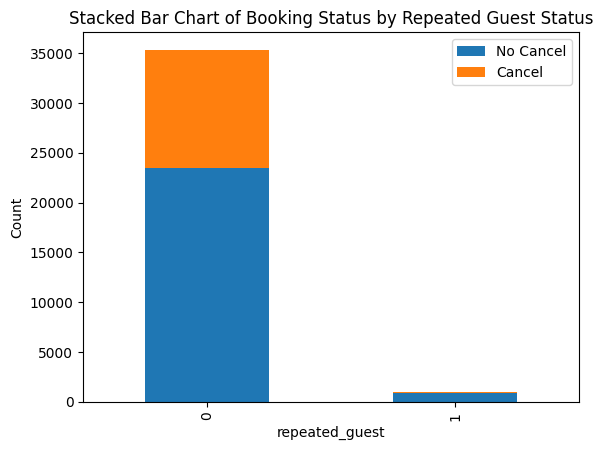

In [63]:
##repeated_guest
ct_repeated_guest = pd.crosstab(hotel_data['repeated_guest'], hotel_data['booking_status'])
ct_repeated_guest.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Repeated Guest Status')
plt.legend(["No Cancel", "Cancel"])
plt.show()

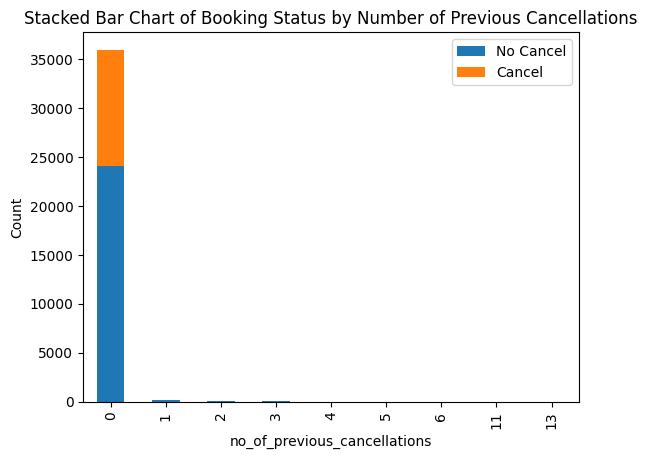

In [64]:
##no_of_previous_cancellations
ct_no_of_previous_cancellations = pd.crosstab(hotel_data['no_of_previous_cancellations'], hotel_data['booking_status'])
ct_no_of_previous_cancellations.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Number of Previous Cancellations')
plt.legend(["No Cancel", "Cancel"])
plt.show()

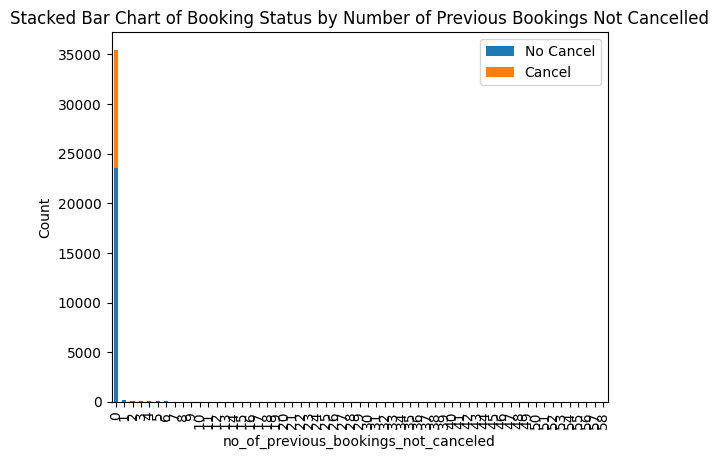

In [65]:
##no_of_previous_bookings_not_cancelled
ct_no_of_previous_bookings_not_canceled = pd.crosstab(hotel_data['no_of_previous_bookings_not_canceled'], hotel_data['booking_status'])
ct_no_of_previous_bookings_not_canceled.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Number of Previous Bookings Not Cancelled')
plt.legend(["No Cancel", "Cancel"])
plt.show()

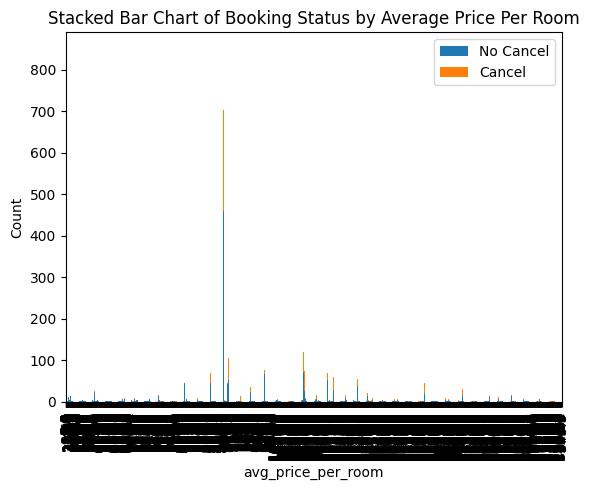

In [66]:
##avg_price_per_room - put into buckets similar to lead time
ct_avg_price_per_room = pd.crosstab(hotel_data['avg_price_per_room'], hotel_data['booking_status'])
ct_avg_price_per_room.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Average Price Per Room')
plt.legend(["No Cancel", "Cancel"])
plt.show()

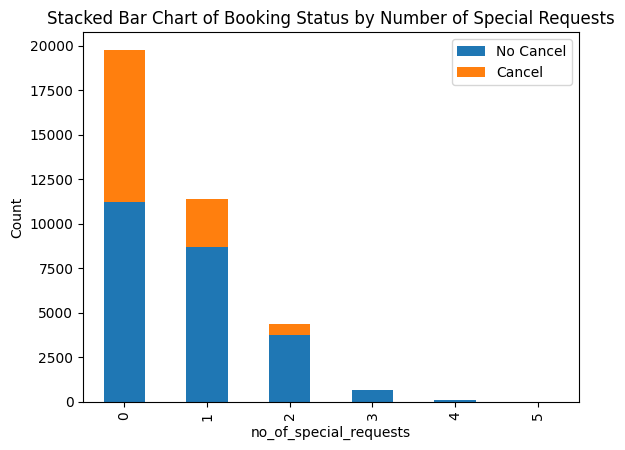

In [67]:
##no_of_special_requests
ct_no_of_special_requests = pd.crosstab(hotel_data['no_of_special_requests'], hotel_data['booking_status'])
ct_no_of_special_requests.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Number of Special Requests')
plt.legend(["No Cancel", "Cancel"])
plt.show()

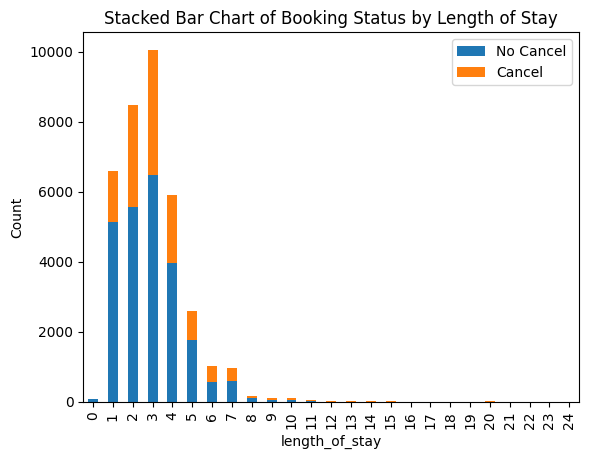

In [68]:
##length_of_stay - put into buckets as well
ct_length_of_stay = pd.crosstab(hotel_data['length_of_stay'], hotel_data['booking_status'])
ct_length_of_stay.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Length of Stay')
plt.legend(["No Cancel", "Cancel"])
plt.show()

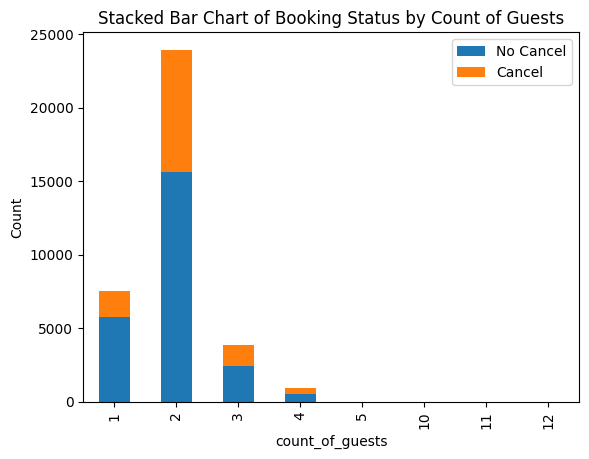

In [69]:
##count_of_guests
ct_count_of_guests = pd.crosstab(hotel_data['count_of_guests'], hotel_data['booking_status'])
ct_count_of_guests.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Count of Guests')
plt.legend(["No Cancel", "Cancel"])
plt.show()

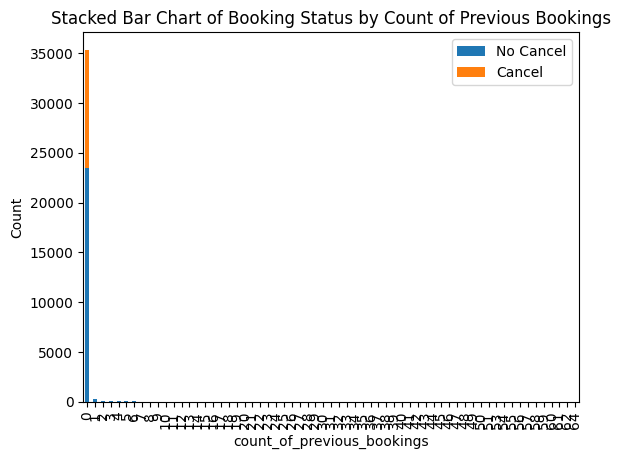

In [70]:
##count_of_previous_bookings
ct_count_of_previous_bookings = pd.crosstab(hotel_data['count_of_previous_bookings'], hotel_data['booking_status'])
ct_count_of_previous_bookings.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Count of Previous Bookings')
plt.legend(["No Cancel", "Cancel"])
plt.show()

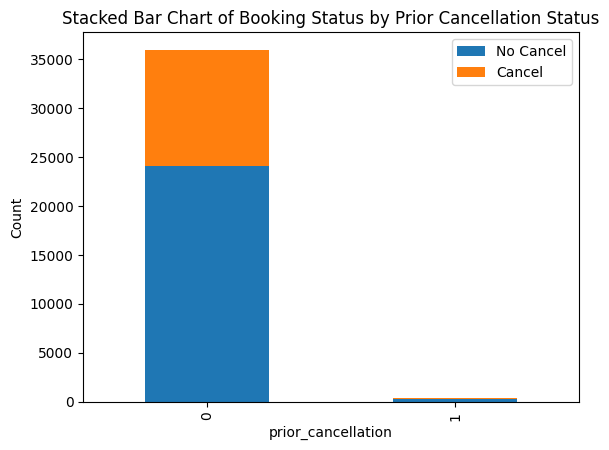

In [71]:
##prior_cancellation
ct_prior_cancellation = pd.crosstab(hotel_data['prior_cancellation'], hotel_data['booking_status'])
ct_prior_cancellation.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Prior Cancellation Status')
plt.legend(["No Cancel", "Cancel"])
plt.show()

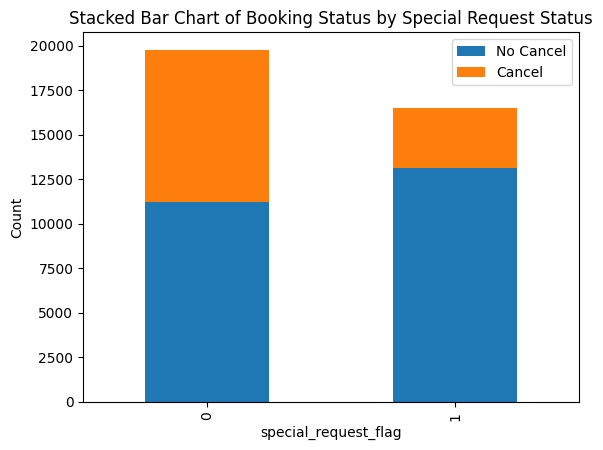

In [72]:
##special_request_flag
ct_special_request_flag = pd.crosstab(hotel_data['special_request_flag'], hotel_data['booking_status'])
ct_special_request_flag.plot(kind='bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by Special Request Status')
plt.legend(["No Cancel", "Cancel"])
plt.show()

In [73]:
#Put lead_time, avg_price_per_room, length_of_stay into Low, Medium, High buckets based on mean or median values,
#then do another histogram for each to parse out more useful data. Could also just do low/high.

##lead_time - skewed so make buckets based on median
hotel_data['lead_time'].mean()

85.23255685733976

In [74]:
hotel_data['lead_time'].median()

57.0

In [75]:
##avg_price_per_room - not skewed so make buckets based on mean
hotel_data['avg_price_per_room'].mean()

103.42353907649897

In [76]:
hotel_data['avg_price_per_room'].median()

99.45

In [77]:
##length_of_stay - not skewed so make buckets based on mean
hotel_data['length_of_stay'].mean()

3.0150241212956583

In [78]:
hotel_data['length_of_stay'].median()

3.0

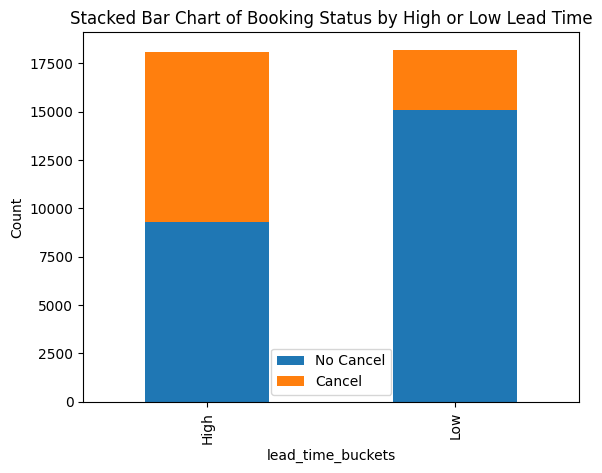

In [79]:
##lead time bucket with bivariate visualization
median_lead_time = hotel_data['lead_time'].median()
hotel_data['lead_time_buckets'] = hotel_data['lead_time'].apply(lambda x: 'Low' if x <= median_lead_time else 'High')

ct_lead_time_buckets = pd.crosstab(hotel_data['lead_time_buckets'], hotel_data['booking_status'])
ct_lead_time_buckets.plot(kind = 'bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by High or Low Lead Time')
plt.legend(["No Cancel", "Cancel"])
plt.show()

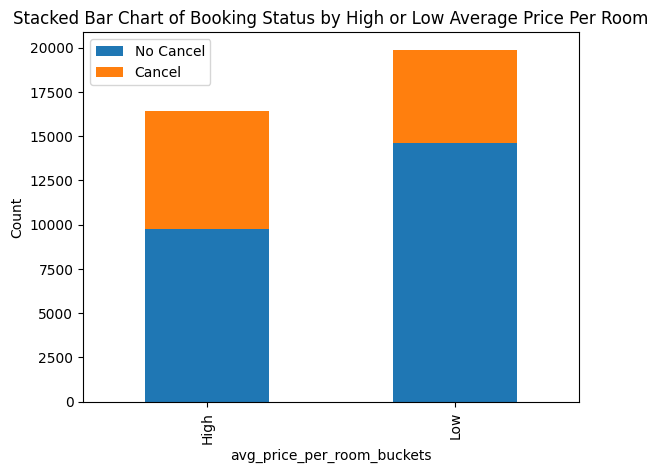

In [80]:
##avg price per room bucket with bivariate visualization
mean_avg_price_per_room = hotel_data['avg_price_per_room'].mean()
hotel_data['avg_price_per_room_buckets'] = hotel_data['avg_price_per_room'].apply(lambda x: 'Low' if x <= mean_avg_price_per_room else 'High')

ct_avg_price_per_room_buckets = pd.crosstab(hotel_data['avg_price_per_room_buckets'], hotel_data['booking_status'])
ct_avg_price_per_room_buckets.plot(kind = 'bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by High or Low Average Price Per Room')
plt.legend(["No Cancel", "Cancel"])
plt.show()

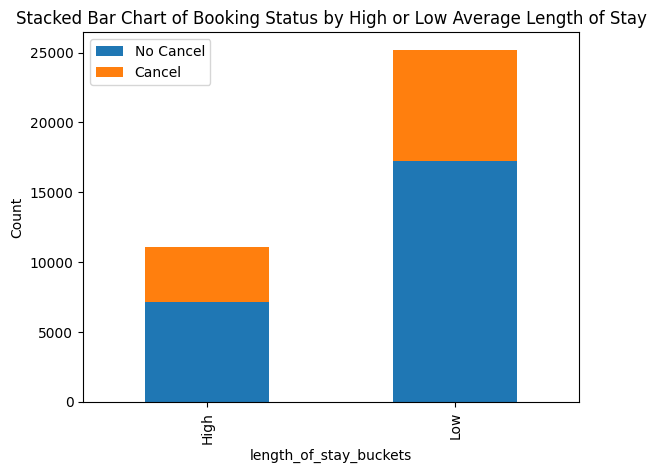

In [81]:
##length of stay bucket with bivariate visualization
mean_length_of_stay = hotel_data['length_of_stay'].mean()
hotel_data['length_of_stay_buckets'] = hotel_data['length_of_stay'].apply(lambda x: 'Low' if x <= mean_length_of_stay else 'High')

ct_mean_length_of_stay_buckets = pd.crosstab(hotel_data['length_of_stay_buckets'], hotel_data['booking_status'])
ct_mean_length_of_stay_buckets.plot(kind = 'bar', stacked=True)
plt.ylabel('Count')
plt.title('Stacked Bar Chart of Booking Status by High or Low Average Length of Stay')
plt.legend(["No Cancel", "Cancel"])
plt.show()

In [82]:
#Check value counts for categorical variables to see if they can/should be re-encoded
##'type_of_meal_plan', 'room_type_reserved', 'market_segment_type'
print(hotel_data['type_of_meal_plan'].value_counts()) #Don't have dictionary info of which type means what, 
#but can split it into "Selected a Meal Plan" versus "Did not select a meal plan"

type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64


In [83]:
print(hotel_data['room_type_reserved'].value_counts()) #Don't have dictionary info of which type means what

room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64


In [84]:
print(hotel_data['market_segment_type'].value_counts()) #Online 1, Other 0

market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64


In [85]:
#Categorical variable re-expression via one-hot encoding - room_type_reserved not included since no dictionary
##type_of_meal_plan (Selected Meal Plan: 1, Did not Select Meal Plan: 0)
hotel_data['type_of_meal_plan'].unique()

array(['Meal Plan 1', 'Not Selected', 'Meal Plan 2', 'Meal Plan 3'],
      dtype=object)

In [86]:
hotel_data['selected_meal_plan'] = hotel_data['type_of_meal_plan'].replace({"Meal Plan 1": 1, "Meal Plan 2": 1, "Meal Plan 3": 1, "Not Selected": 0})
hotel_data['selected_meal_plan'].value_counts()

C:\Users\matth\AppData\Local\Temp\ipykernel_12488\2570540558.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hotel_data['selected_meal_plan'] = hotel_data['type_of_meal_plan'].replace({"Meal Plan 1": 1, "Meal Plan 2": 1, "Meal Plan 3": 1, "Not Selected": 0})


selected_meal_plan
1    31145
0     5130
Name: count, dtype: int64

In [87]:
##market_segment_type (Online: 1, Other 0)
hotel_data['market_segment_type'].unique()

array(['Offline', 'Online', 'Corporate', 'Aviation', 'Complementary'],
      dtype=object)

In [88]:
hotel_data['online_reservation'] = hotel_data['market_segment_type'].replace({"Online": 1, "Offline": 0, "Corporate": 0, "Aviation": 0, "Complementary": 0})
hotel_data['online_reservation'].value_counts()

C:\Users\matth\AppData\Local\Temp\ipykernel_12488\920506920.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hotel_data['online_reservation'] = hotel_data['market_segment_type'].replace({"Online": 1, "Offline": 0, "Corporate": 0, "Aviation": 0, "Complementary": 0})


online_reservation
1    23214
0    13061
Name: count, dtype: int64

In [89]:
##Convert remaining objects to numerical for use in logistic regression
hotel_data['lead_time_buckets'] = hotel_data['lead_time_buckets'].map({'Low': 0, 'High': 1})
hotel_data['avg_price_per_room_buckets'] = hotel_data['avg_price_per_room_buckets'].map({'Low': 0, 'High': 1})
hotel_data['length_of_stay_buckets'] = hotel_data['length_of_stay_buckets'].map({'Low': 0, 'High': 1})

In [90]:
hotel_data['lead_time_buckets'].value_counts()

lead_time_buckets
0    18202
1    18073
Name: count, dtype: int64

In [91]:
hotel_data['avg_price_per_room_buckets'].value_counts()

avg_price_per_room_buckets
0    19876
1    16399
Name: count, dtype: int64

In [92]:
hotel_data['length_of_stay_buckets'].value_counts()

length_of_stay_buckets
0    25206
1    11069
Name: count, dtype: int64

In [93]:
#Construct initial logistic regression model 
print(hotel_data.dtypes)

Booking_ID                                       object
no_of_adults                                      int64
no_of_children                                    int64
no_of_weekend_nights                              int64
no_of_week_nights                                 int64
type_of_meal_plan                                object
required_car_parking_space                        int64
room_type_reserved                               object
lead_time                                         int64
arrival_year                                      int64
arrival_month                                     int64
arrival_date                                      int64
market_segment_type                              object
repeated_guest                                    int64
no_of_previous_cancellations                      int64
no_of_previous_bookings_not_canceled              int64
avg_price_per_room                              float64
no_of_special_requests                          

In [94]:
independent_variables = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space',
                         'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations',
                         'no_of_previous_bookings_not_canceled', 'no_of_special_requests',
                         'count_of_guests', 'count_of_previous_bookings', 'prior_cancellation', 'special_request_flag',
                         'online_reservation', 'selected_meal_plan', 'lead_time_buckets', 'avg_price_per_room_buckets',
                         'length_of_stay_buckets']
X = hotel_data[independent_variables]
y = hotel_data['booking_status']

X = sm.add_constant(X)
initial_model = sm.Logit(y, X)
initial_result = initial_model.fit()
print(initial_result.summary())

         Current function value: 0.472862
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                36275
Model:                          Logit   Df Residuals:                    36254
Method:                           MLE   Df Model:                           20
Date:                Wed, 08 Jan 2025   Pseudo R-squ.:                  0.2524
Time:                        11:59:41   Log-Likelihood:                -17153.
converged:                      False   LL-Null:                       -22944.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                -2126.4971     88.931    -23.912      0.000   -2300.799

C:\Users\matth\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


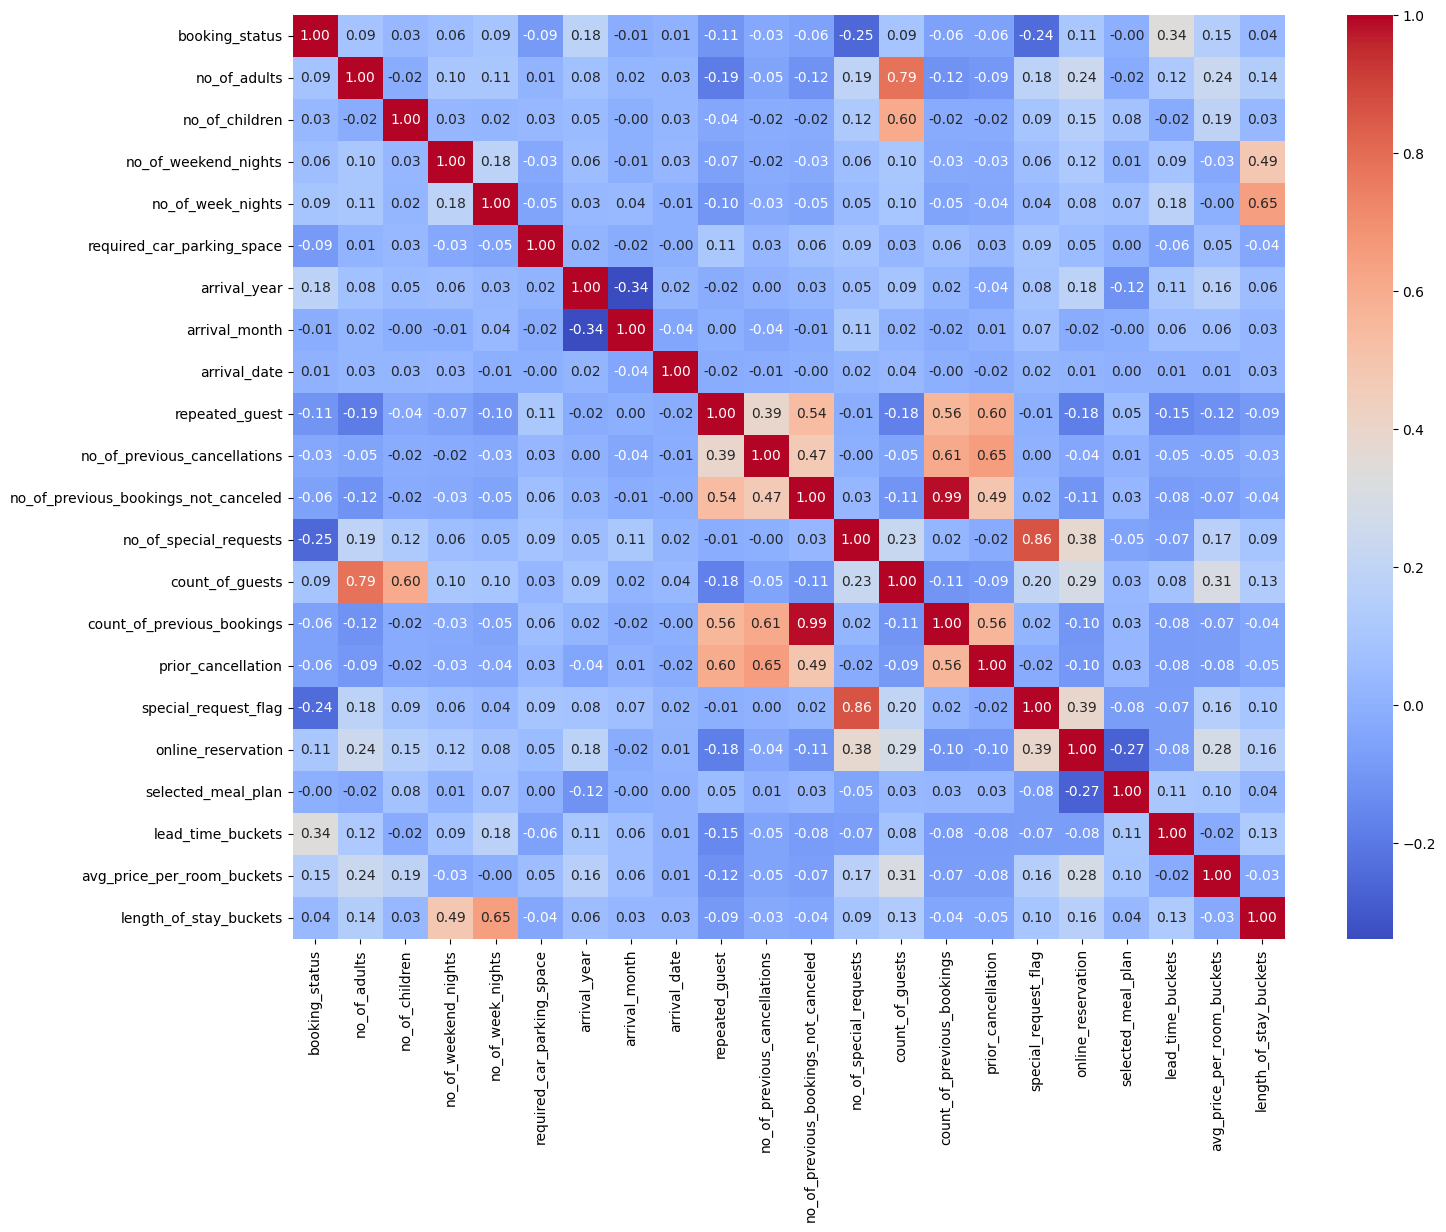

In [95]:
#Correlation matrix
hotel_data_for_corr = hotel_data[['booking_status', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space',
                         'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations',
                         'no_of_previous_bookings_not_canceled', 'no_of_special_requests',
                         'count_of_guests', 'count_of_previous_bookings', 'prior_cancellation', 'special_request_flag',
                         'online_reservation', 'selected_meal_plan', 'lead_time_buckets', 'avg_price_per_room_buckets',
                         'length_of_stay_buckets']]
corr_matrix = hotel_data_for_corr.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

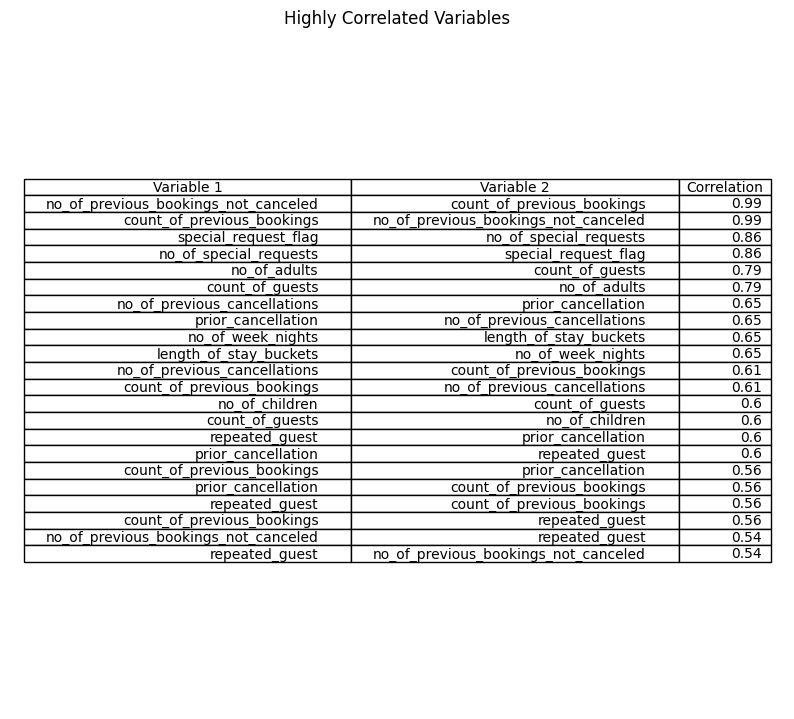

In [96]:
##Table of the highest correlated values (anything over 0.5?)
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

high_corr = corr_pairs[(corr_pairs['Correlation'] > 0.5) & (corr_pairs['Variable 1'] != corr_pairs['Variable 2'])]
high_corr = high_corr.sort_values(by='Correlation', ascending=False)
high_corr['Correlation'] = high_corr['Correlation'].round(2)  # Limit to 2 decimal places


fig, ax = plt.subplots(figsize=(10, len(high_corr) * 0.4))  # Adjust height based on rows
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=high_corr.values,  # Data to display
    colLabels=high_corr.columns,  # Column headers
    loc='center',  # Table position
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(high_corr.columns))))  # Adjust column widths

plt.title("Highly Correlated Variables", fontsize=12)
plt.show()

In [97]:
#Remove highly correlated variables (we know some of them are multicollinear because we derived some columns from other columns)
#Then run the logit model again as our new model
#Dropped variables will be the ones that showed less valuable info in the bivariate visualizations than their derived counterparts
##Going the drop the following: 'no_of_previous_bookings_not_canceled', 'no_of_week_nights', 'no_of_special_requests',
## 'no_of_previous_cancellations', 'no_of_children', 'no_of_weekend_nights', 'no_of_adults'
independent_variables = ['required_car_parking_space','arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
                         'count_of_guests', 'count_of_previous_bookings', 'prior_cancellation', 'special_request_flag',
                         'online_reservation', 'selected_meal_plan', 'lead_time_buckets', 'avg_price_per_room_buckets',
                         'length_of_stay_buckets']
X = hotel_data[independent_variables]
y = hotel_data['booking_status']

X = sm.add_constant(X)
model1 = sm.Logit(y, X)
result1 = model1.fit()
print(result1.summary())

         Current function value: 0.485106
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                36275
Model:                          Logit   Df Residuals:                    36260
Method:                           MLE   Df Model:                           14
Date:                Wed, 08 Jan 2025   Pseudo R-squ.:                  0.2330
Time:                        12:00:04   Log-Likelihood:                -17597.
converged:                      False   LL-Null:                       -22944.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                      -2120.1619     88.035    -24.083      0.000   -2292.706   -1947.617
required_car_park

C:\Users\matth\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


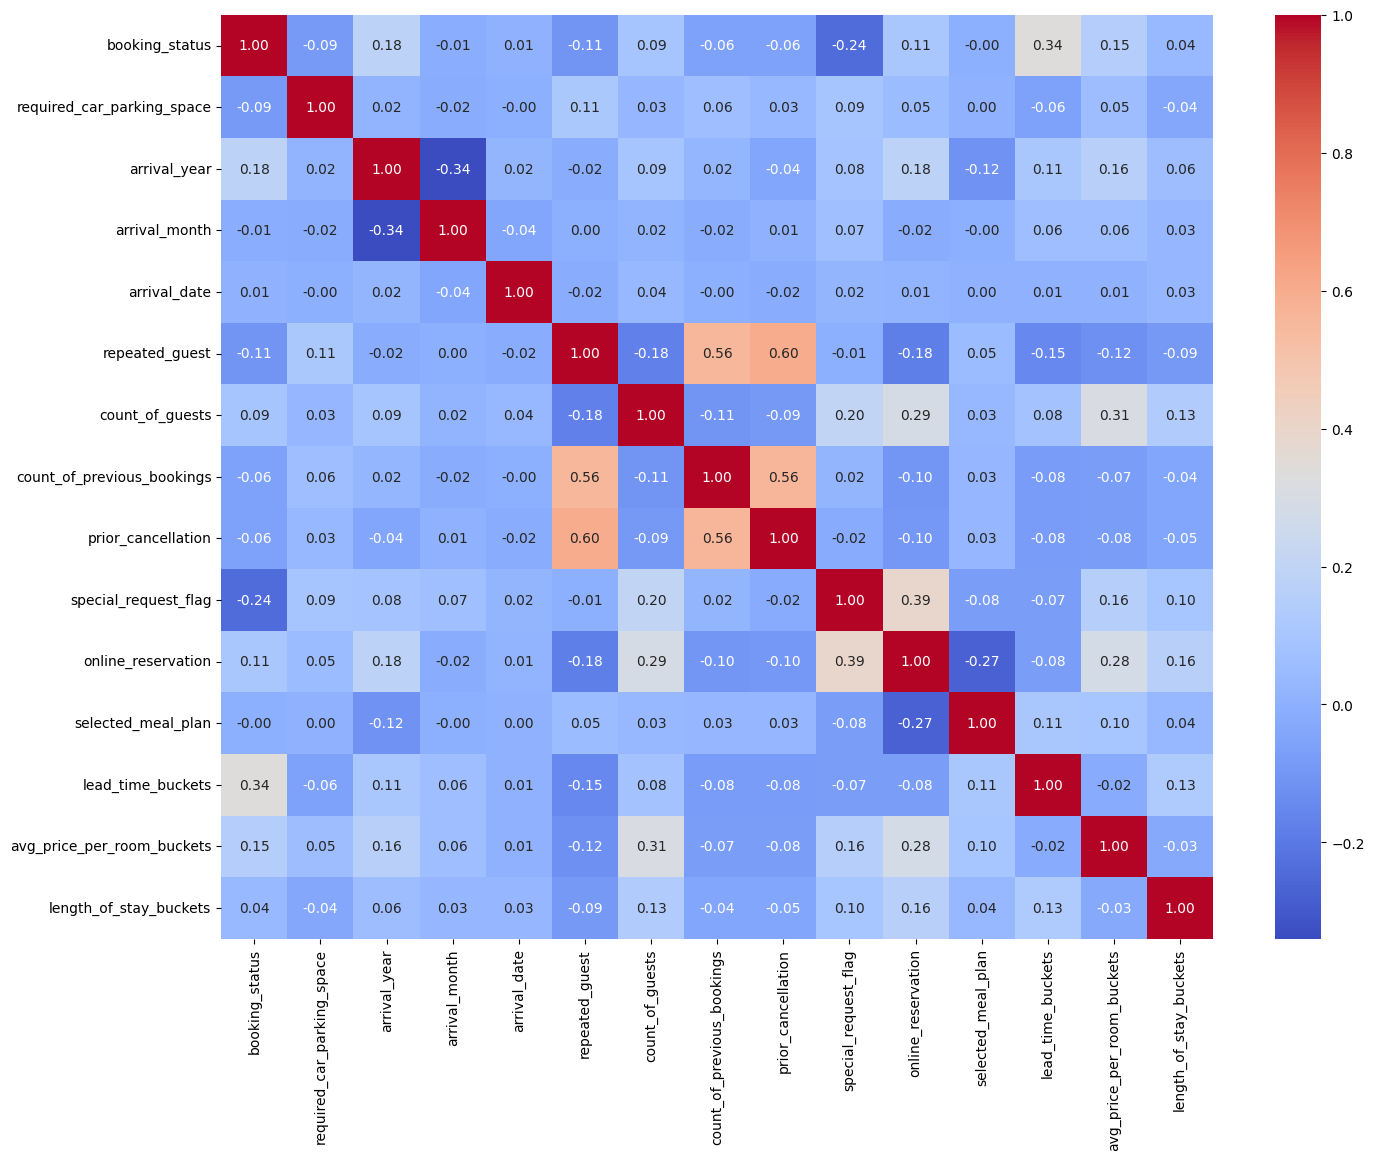

In [98]:
hotel_data_for_corr = hotel_data[['booking_status', 'required_car_parking_space','arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
                         'count_of_guests', 'count_of_previous_bookings', 'prior_cancellation', 'special_request_flag',
                         'online_reservation', 'selected_meal_plan', 'lead_time_buckets', 'avg_price_per_room_buckets',
                         'length_of_stay_buckets']]
corr_matrix = hotel_data_for_corr.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [99]:
#Feature selection via VIF
hotel_data_vif = hotel_data_for_corr.drop(['booking_status'], axis=1)
print(hotel_data_vif.columns)

vif_data = pd.DataFrame()
vif_data["feature"] = hotel_data_vif.columns

vif_data["VIF"] = [variance_inflation_factor(hotel_data_vif.values, i)
for i in range(len(hotel_data_vif.columns))]
print(vif_data)

Index(['required_car_parking_space', 'arrival_year', 'arrival_month',
       'arrival_date', 'repeated_guest', 'count_of_guests',
       'count_of_previous_bookings', 'prior_cancellation',
       'special_request_flag', 'online_reservation', 'selected_meal_plan',
       'lead_time_buckets', 'avg_price_per_room_buckets',
       'length_of_stay_buckets'],
      dtype='object')
                       feature        VIF
0   required_car_parking_space   1.063676
1                 arrival_year  27.468311
2                arrival_month   6.989041
3                 arrival_date   4.203395
4               repeated_guest   1.914826
5              count_of_guests  12.180620
6   count_of_previous_bookings   1.670996
7           prior_cancellation   1.797029
8         special_request_flag   2.249881
9           online_reservation   4.188630
10          selected_meal_plan   8.102367
11           lead_time_buckets   2.143051
12  avg_price_per_room_buckets   2.222835
13      length_of_stay_buckets   1

In [100]:
#Remove VIF over 5
hotel_data_vif_2 = hotel_data_vif.drop(['arrival_year', 'arrival_month', 'count_of_guests', 'selected_meal_plan'], axis = 1)
hotel_data_vif_2.head()
vif_data = pd.DataFrame()
vif_data["feature"] = hotel_data_vif_2.columns

vif_data["VIF"] = [variance_inflation_factor(hotel_data_vif_2.values, i)
for i in range(len(hotel_data_vif_2.columns))]
print(vif_data)

                      feature       VIF
0  required_car_parking_space  1.062105
1                arrival_date  2.605990
2              repeated_guest  1.841136
3  count_of_previous_bookings  1.668989
4          prior_cancellation  1.795197
5        special_request_flag  2.177167
6          online_reservation  3.257122
7           lead_time_buckets  1.763778
8  avg_price_per_room_buckets  1.926911
9      length_of_stay_buckets  1.512352


In [101]:
#Remove 'arrival_year', 'arrival_month', 'count_of_guests' 'selected_meal_plan' and try Logit model again
independent_variables = ['required_car_parking_space', 'arrival_date', 'repeated_guest',
                         'count_of_previous_bookings', 'prior_cancellation', 'special_request_flag',
                         'online_reservation', 'lead_time_buckets', 'avg_price_per_room_buckets',
                         'length_of_stay_buckets']
X = hotel_data[independent_variables]
y = hotel_data['booking_status']

X = sm.add_constant(X)
model2 = sm.Logit(y, X)
result2 = model2.fit()
print(result2.summary())

         Current function value: 0.494648
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                36275
Model:                          Logit   Df Residuals:                    36264
Method:                           MLE   Df Model:                           10
Date:                Wed, 08 Jan 2025   Pseudo R-squ.:                  0.2179
Time:                        12:00:26   Log-Likelihood:                -17943.
converged:                      False   LL-Null:                       -22944.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -2.2242      0.040    -55.595      0.000      -2.303      -2.146
required_car_park

C:\Users\matth\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [102]:
#Feature selection via backward stepwise elimination (until all remaining are significant)
##Remove least significant variable and regress again (prior_cancellation)
independent_variables = ['required_car_parking_space', 'arrival_date', 'repeated_guest',
                         'count_of_previous_bookings', 'special_request_flag',
                         'online_reservation', 'lead_time_buckets', 'avg_price_per_room_buckets',
                         'length_of_stay_buckets']
X = hotel_data[independent_variables]
y = hotel_data['booking_status']

X = sm.add_constant(X)
model3 = sm.Logit(y, X)
result3 = model3.fit()
print(result3.summary())

Optimization terminated successfully.
         Current function value: 0.494947
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                36275
Model:                          Logit   Df Residuals:                    36265
Method:                           MLE   Df Model:                            9
Date:                Wed, 08 Jan 2025   Pseudo R-squ.:                  0.2175
Time:                        12:00:32   Log-Likelihood:                -17954.
converged:                       True   LL-Null:                       -22944.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -2.2252      0.040    -55.611      0.000      

In [103]:
##Remove least significant variable and regress again (count_of_previous_bookings)
independent_variables = ['required_car_parking_space', 'arrival_date', 'repeated_guest',
                         'special_request_flag', 'online_reservation', 'lead_time_buckets', 
                         'avg_price_per_room_buckets', 'length_of_stay_buckets']
X = hotel_data[independent_variables]
y = hotel_data['booking_status']

X = sm.add_constant(X)
model4 = sm.Logit(y, X)
result4 = model4.fit()
print(result4.summary())

Optimization terminated successfully.
         Current function value: 0.494948
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                36275
Model:                          Logit   Df Residuals:                    36266
Method:                           MLE   Df Model:                            8
Date:                Wed, 08 Jan 2025   Pseudo R-squ.:                  0.2175
Time:                        12:00:37   Log-Likelihood:                -17954.
converged:                       True   LL-Null:                       -22944.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -2.2252      0.040    -55.612      0.000      

In [104]:
##Remove least significant variable and regress again (length_of_stay_buckets)
independent_variables = ['required_car_parking_space', 'arrival_date', 'repeated_guest',
                         'special_request_flag', 'online_reservation', 'lead_time_buckets', 
                         'avg_price_per_room_buckets']
X = hotel_data[independent_variables]
y = hotel_data['booking_status']

X = sm.add_constant(X)
model5 = sm.Logit(y, X)
result5 = model5.fit()
print(result5.summary())

Optimization terminated successfully.
         Current function value: 0.494986
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                36275
Model:                          Logit   Df Residuals:                    36267
Method:                           MLE   Df Model:                            7
Date:                Wed, 08 Jan 2025   Pseudo R-squ.:                  0.2174
Time:                        12:00:40   Log-Likelihood:                -17956.
converged:                       True   LL-Null:                       -22944.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -2.2305      0.040    -55.927      0.000      

In [105]:
##Remove least significant variable and regress again (arrival_date)
independent_variables = ['required_car_parking_space', 'repeated_guest',
                         'special_request_flag', 'online_reservation', 'lead_time_buckets', 
                         'avg_price_per_room_buckets']
X = hotel_data[independent_variables]
y = hotel_data['booking_status']

X = sm.add_constant(X)
final_model = sm.Logit(y, X)
final_result = final_model.fit()
print(final_result.summary())

Optimization terminated successfully.
         Current function value: 0.495038
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                36275
Model:                          Logit   Df Residuals:                    36268
Method:                           MLE   Df Model:                            6
Date:                Wed, 08 Jan 2025   Pseudo R-squ.:                  0.2173
Time:                        12:00:43   Log-Likelihood:                -17958.
converged:                       True   LL-Null:                       -22944.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -2.1864      0.033    -66.706      0.000      

Text(0.5, 427.9555555555555, 'Predicted label')

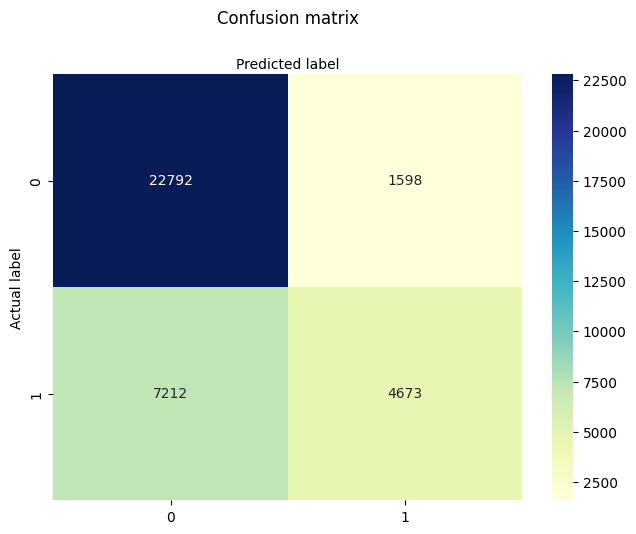

In [106]:
#Confusion matrix
y_prob = final_result.predict(X)

##Convert probabilities to binary predictions based on a threshold
threshold = 0.5
y_pred = np.where(y_prob > threshold, 1, 0)

##Generate confusion matrix
cnf_matrix = confusion_matrix(y, y_pred)

##Visualize results using Heatmap (Code borrowed from https://www.datacamp.com/tutorial/understanding-logistic-regression-python)
class_names=[0,1] #name of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
##Create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [107]:
#Calculate accuracy score
TN = 22792
FP = 1598
FN = 7212
TP = 4673

accuracy_score = (TP+TN)/(TP + TN + FP + FN)
print(accuracy_score)

0.7571330117160578
